# Notebook 08b — LightGBM Regression: Weather Effects on Cycling Demand

Fits **LightGBM (regression objective on log-adjusted counts)** with **SHAP** for interpretation.

Target: `y_adj = log1p(aantal) - site_offset` — same as XGBoost (notebook 08c).
Prediction is restored to raw count scale via `expm1(ŷ_adj + site_offset)`.


## 0. Imports & Setup

In [24]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lightgbm", "shap"])


0

In [25]:
import pickle
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

COLORS = {
    "commuter" : "#2196F3",
    "mixed"    : "#FFC107",
    "leisure"  : "#F44336",
}

# analysis_panel already contains lat / long; only pull commute_score + site_type from site_cls
panel = pd.read_parquet(PROCESSED / "analysis_panel.parquet")

site_cls = pd.read_parquet(PROCESSED / "site_classification.parquet")[
    ["site ID", "site_type", "commute_score"]
]
panel = panel.merge(site_cls, on="site ID", how="left")
panel["site_type"] = panel["site_type"].fillna("unclassified")

panel_good = panel[
    (panel["low_coverage"] == False) &
    (panel["aantal"].notna()) &
    (panel["temp_avg"].notna())
].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

print(f"Date range : {panel_good['date'].min().date()}  →  {panel_good['date'].max().date()}")
print(f"Total rows : {len(panel_good):,}")
print("\nRows per year:")
print(panel_good['date'].dt.year.value_counts().sort_index().to_string())
print("\nsite_type distribution:")
print(panel_good['site_type'].value_counts().to_string())

Date range : 2023-01-01  →  2025-12-31
Total rows : 144,338

Rows per year:
date
2023    47836
2024    48351
2025    48151

site_type distribution:
site_type
commuter    72143
leisure     44342
mixed       27853


## 0b. Train-only IQR Outlier Audit

Identical to notebook 08 — kept for reproducibility.


In [26]:
# ── per-site IQR stats on train only ──────────────────────────────────
def site_stats(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    return pd.Series({"q1": q1, "q3": q3, "iqr": iqr,
                      "median": x.median(), "upper_fence": q3 + 3 * iqr})

_train_for_iqr = panel_good[panel_good["date"].dt.year.isin([2023, 2024])].copy()
_stats = _train_for_iqr.groupby("site ID")["aantal"].apply(site_stats).unstack()
_train_for_iqr = _train_for_iqr.merge(_stats, on="site ID")

_outliers = _train_for_iqr[
    (_train_for_iqr["aantal"] > _train_for_iqr["upper_fence"]) &
    (_train_for_iqr["iqr"] > 0)
].copy()
_outliers["ratio"] = (_outliers["aantal"] / _outliers["median"]).round(1)

print(f"Total flagged (Q3 + 3×IQR, train 2023-2024): {len(_outliers)}")

_candidates = _outliers[_outliers["ratio"] >= 5][
    ["site ID", "naam", "date", "aantal", "median", "upper_fence", "ratio"]
].copy()
_site_max = _candidates.groupby("site ID")["ratio"].max().rename("site_max")
_candidates = (_candidates
    .merge(_site_max, on="site ID")
    .sort_values(["site_max", "site ID", "ratio"], ascending=[False, True, False])
    .drop(columns="site_max")
)
print()
print("=" * 80)
print("CANDIDATES WITH RATIO >= 5x MEDIAN  (grouped by site, down ratio)")
print("=" * 80)
_current_site = None
for _, row in _candidates.iterrows():
    if row["site ID"] != _current_site:
        _current_site = row["site ID"]
        site_n = _candidates[_candidates["site ID"] == _current_site].shape[0]
        print(f"\n  site {int(row['site ID']):<4}  {row['naam']}  [{site_n} flagged date(s)]")
    print(f"    {str(row['date'])[:10]}  aantal={int(row['aantal']):>6}  "
          f"median={row['median']:>6.1f}  fence={row['upper_fence']:>8.1f}  ratio={row['ratio']:.1f}x")


Total flagged (Q3 + 3×IQR, train 2023-2024): 125

CANDIDATES WITH RATIO >= 5x MEDIAN  (grouped by site, down ratio)

  site 105   St. pieters leeuw teller 2  [1 flagged date(s)]
    2023-03-03  aantal=   807  median=   0.0  fence=   232.0  ratio=infx

  site 85    Asse teller 1  [3 flagged date(s)]
    2024-07-25  aantal=  4823  median=  82.0  fence=   268.0  ratio=58.8x
    2024-07-21  aantal=   904  median=  82.0  fence=   268.0  ratio=11.0x
    2024-07-07  aantal=   660  median=  82.0  fence=   268.0  ratio=8.0x

  site 83    Beersel teller 2  [16 flagged date(s)]
    2024-03-31  aantal=  1796  median=  46.0  fence=   141.0  ratio=39.0x
    2024-03-19  aantal=  1748  median=  46.0  fence=   141.0  ratio=38.0x
    2024-03-30  aantal=  1720  median=  46.0  fence=   141.0  ratio=37.4x
    2024-04-06  aantal=  1534  median=  46.0  fence=   141.0  ratio=33.3x
    2024-03-29  aantal=  1443  median=  46.0  fence=   141.0  ratio=31.4x
    2024-04-01  aantal=  1217  median=  46.0  fence=   1

## 0c. Outlier Blacklist, Event Flags & Train/Test Split

Identical to notebook 08.


In [27]:
# ── outlier blacklist (informed by IQR audit above) ───────────────────
remove_dates = [
    (105, '2023-03-03'),
    (85,  '2024-07-25'),
    (20,  '2024-06-02'),
    (140, '2024-07-13'),
    (129, '2024-08-12'),
    (78,  '2023-07-01'),
    (50,  '2024-09-18'),
    (94,  '2023-08-20'),
    (33,  '2023-01-20'),
    (81,  '2024-08-18'),
    (83,  '2024-03-19'),
    (83,  '2024-03-27'), (83,  '2024-03-28'), (83,  '2024-03-29'),
    (83,  '2024-03-30'), (83,  '2024-03-31'), (83,  '2024-04-01'),
    (83,  '2024-04-02'), (83,  '2024-04-03'), (83,  '2024-04-04'),
    (83,  '2024-04-05'), (83,  '2024-04-06'), (83,  '2024-04-07'),
    (83,  '2024-04-08'), (83,  '2024-04-09'), (83,  '2024-04-10'),
]

event_dates = [
    (70,  '2023-09-16'), (70,  '2024-09-21'),
    (85,  '2024-07-07'), (85,  '2024-07-21'),
    (72,  '2024-05-08'), (51,  '2024-05-08'),
    (43,  '2023-05-28'), (44,  '2023-05-28'),
    (28,  '2024-04-06'), (28,  '2024-04-13'), (28,  '2024-04-14'),
    (28,  '2023-04-30'), (28,  '2023-05-01'), (28,  '2023-05-04'),
    (34,  '2024-04-06'), (34,  '2023-04-30'), (34,  '2023-06-03'),
    (14,  '2023-09-24'), (14,  '2024-09-22'),
    (48,  '2024-09-18'), (48,  '2024-09-19'), (48,  '2024-09-20'),
    (48,  '2024-09-21'), (48,  '2024-09-22'),
]

remove_set = set((s, d) for s, d in remove_dates)
event_set  = set((s, d) for s, d in event_dates)

remove_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in remove_set, axis=1
)
panel_good.loc[remove_mask, 'aantal'] = np.nan
print(f'Removed {remove_mask.sum()} extreme outlier rows')

event_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in event_set, axis=1
)
panel_good['is_event_day'] = event_mask.astype(int)
print(f'Flagged {event_mask.sum()} recurring event days')

print("\n" + "─" * 40)
train = panel_good[panel_good["date"].dt.year.isin([2023, 2024])].copy()
test  = panel_good[panel_good["date"].dt.year == 2025].copy()

# Year-based split: 2023 trains, 2024 validates (no leakage into offset)
train_2023 = train[train["date"].dt.year == 2023].copy()
val_2024   = train[train["date"].dt.year == 2024].copy()

# Offset for early-stopping validation: computed from 2023 only
site_offset_val = (
    train_2023.groupby("site ID")["aantal"]
    .apply(lambda x: np.log1p(x).mean())
    .reset_index()
    .rename(columns={"aantal": "site_offset"})
)

# Offset for final model & 2025 test: computed from 2023+2024
site_offset_test = (
    train.groupby("site ID")["aantal"]
    .apply(lambda x: np.log1p(x).mean())
    .reset_index()
    .rename(columns={"aantal": "site_offset"})
)

train_2023 = train_2023.merge(site_offset_val,  on="site ID", how="left")
val_2024   = val_2024.merge(site_offset_val,    on="site ID", how="left")
train      = train.merge(site_offset_test,      on="site ID", how="left")
test       = test.merge(site_offset_test,       on="site ID", how="left")
panel_good = panel_good.merge(site_offset_test, on="site ID", how="left")

print(f"Train size : {len(train):,} rows (2023–2024)")
print(f"Test size  : {len(test):,} rows (2025)")


Removed 26 extreme outlier rows
Flagged 24 recurring event days

────────────────────────────────────────
Train size : 96,187 rows (2023–2024)
Test size  : 48,151 rows (2025)


## 1. Feature Engineering

In [28]:
# Encode boolean features as integers
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    train[col]      = train[col].astype(int)
    test[col]       = test[col].astype(int)
    panel_good[col] = panel_good[col].astype(int)

# Weather + calendar features + site-level geographic/classification attributes
ALL_FEATURES = [
    "temp_avg", "precip_total", "wind_avg",
    "sunshine_min", "humidity_avg",
    "temp_avg_lag1", "precip_total_lag1", "wind_avg_lag1",
    "dayofweek", "month",
    "is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day",
    "commute_score", "lat", "long",
]

# Categorical features (by name — must match ALL_FEATURES exactly)
CAT_FEATURES = [
    "dayofweek", "month",
    "is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day",
]

print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"Categorical : {CAT_FEATURES}")
print(f"Train shape: {train.shape}  |  Test shape: {test.shape}")

Features (17): ['temp_avg', 'precip_total', 'wind_avg', 'sunshine_min', 'humidity_avg', 'temp_avg_lag1', 'precip_total_lag1', 'wind_avg_lag1', 'dayofweek', 'month', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'is_event_day', 'commute_score', 'lat', 'long']
Categorical : ['dayofweek', 'month', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'is_event_day']
Train shape: (96187, 58)  |  Test shape: (48151, 58)


## 2. Prepare Feature Matrix

Target: `y_adj = log1p(aantal) - site_offset` (regression on log-adjusted scale, same as XGBoost).
Early stopping uses a clean 2023 → 2024 year split to avoid data leakage.

In [29]:
def make_X_y_with_offset(df, features):
    cols = features + ["aantal", "site_offset"]
    df_clean = df[cols].dropna()
    X     = df_clean[features].values.astype(np.float64)
    y_raw = df_clean["aantal"].values.astype(np.float64)
    y_adj = np.log1p(y_raw) - df_clean["site_offset"].values
    return X, y_adj, y_raw, df_clean

# Final model: train on 2023+2024, test on 2025
X_train_full, y_train_full, y_train_raw_full, train_clean_full = make_X_y_with_offset(train, ALL_FEATURES)
X_test_full,  y_test_full,  y_test_raw_full,  test_clean_full  = make_X_y_with_offset(test,  ALL_FEATURES)

# Early-stopping split: 2023 → 2024 year split (no leakage)
X_tr_full,  y_tr_full,  _,              _              = make_X_y_with_offset(train_2023, ALL_FEATURES)
X_val_full, y_val_full, y_val_raw_full, val_clean_full = make_X_y_with_offset(val_2024,   ALL_FEATURES)

print(f"Train (2023) : {X_tr_full.shape[0]:,} rows")
print(f"Val   (2024) : {X_val_full.shape[0]:,} rows")
print(f"Test  (2025) : {X_test_full.shape[0]:,} rows")
print(f"y_adj — mean: {y_train_full.mean():.3f}, std: {y_train_full.std():.3f}")


Train (2023) : 47,345 rows
Val   (2024) : 48,055 rows
Test  (2025) : 47,842 rows
y_adj — mean: 0.002, std: 0.707


## 3. LightGBM Hyperparameters & Training Utilities

In [30]:
LGB_PARAMS = dict(
    objective        = "regression",
    metric           = "rmse",
    num_leaves       = 31,
    max_depth        = 6,
    learning_rate    = 0.05,
    n_estimators     = 2000,
    feature_fraction = 0.8,
    bagging_fraction = 0.8,
    bagging_freq     = 5,
    min_child_samples= 50,
    reg_alpha        = 0.05,
    reg_lambda       = 2.0,
    verbose          = -1,
    n_jobs           = -1,
    random_state     = 42,
)

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    print(f"  {label:<12}: MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}")
    return mae, rmse, r2

def train_lgb(X_tr, y_tr, X_val, y_val, feature_names, cat_features):
    """Train LightGBM with early stopping on a held-out validation split."""
    dtrain = lgb.Dataset(X_tr, label=y_tr,
                         feature_name=feature_names,
                         categorical_feature=cat_features)
    dval   = lgb.Dataset(X_val, label=y_val,
                         feature_name=feature_names,
                         categorical_feature=cat_features,
                         reference=dtrain)
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100),
    ]
    model = lgb.train(LGB_PARAMS, dtrain, valid_sets=[dval], callbacks=callbacks)
    print(f"    Best iteration: {model.best_iteration}")
    return model


## 4. Model A — Full LightGBM (all stations)

In [31]:
print("Fitting full LightGBM (regression)...")
lgb_full = train_lgb(X_tr_full, y_tr_full, X_val_full, y_val_full, ALL_FEATURES, CAT_FEATURES)

# Restore to count scale: predict returns y_adj; add offset + expm1
offset_val_full  = val_clean_full["site_offset"].values
offset_test_full = test_clean_full["site_offset"].values

y_pred_val_full  = np.clip(np.expm1(lgb_full.predict(X_val_full)  + offset_val_full),  0, None)
y_pred_test_full = np.clip(np.expm1(lgb_full.predict(X_test_full) + offset_test_full), 0, None)

print("\n" + "=" * 52)
print("MODEL A — Full LightGBM (Regression) Performance")
print("=" * 52)
val_mae_f, val_rmse_f, val_r2_f = evaluate(y_val_raw_full,  y_pred_val_full,  "Val  (2024)")
test_mae,  test_rmse,  test_r2  = evaluate(y_test_raw_full, y_pred_test_full, "Test (2025)")
print("=" * 52)

fi = pd.Series(lgb_full.feature_importance(importance_type="gain"),
               index=ALL_FEATURES).sort_values(ascending=False)
print("\nTop-10 features by gain:")
print(fi.head(10).round(0).to_string())


Fitting full LightGBM (regression)...
[100]	valid_0's rmse: 0.689992
    Best iteration: 132

MODEL A — Full LightGBM (Regression) Performance
  Val  (2024) : MAE=108.0  RMSE=237.3  R²=0.861
  Test (2025) : MAE=121.2  RMSE=245.1  R²=0.880

Top-10 features by gain:
sunshine_min         32758.0
month                18087.0
is_weekend           17038.0
precip_total         10939.0
commute_score        10352.0
dayofweek             7255.0
temp_avg              5265.0
long                  5015.0
wind_avg              4830.0
is_school_holiday     4332.0


## 5. Model B — Commuter LightGBM

In [32]:
train_c = train[train["site_type"] == "commuter"].copy()
test_c  = test[test["site_type"]  == "commuter"].copy()

X_train_c, y_train_c, y_train_c_raw, train_clean_c = make_X_y_with_offset(train_c, ALL_FEATURES)
X_test_c,  y_test_c,  y_test_c_raw,  test_clean_c  = make_X_y_with_offset(test_c,  ALL_FEATURES)

train_c_2023 = train_2023[train_2023["site_type"] == "commuter"].copy()
val_c_2024   = val_2024[val_2024["site_type"]     == "commuter"].copy()

X_tr_c,  y_tr_c,  _,           _            = make_X_y_with_offset(train_c_2023, ALL_FEATURES)
X_val_c, y_val_c, y_val_c_raw, val_clean_c  = make_X_y_with_offset(val_c_2024,   ALL_FEATURES)

print(f"  Train (2023) : {X_tr_c.shape[0]:,} rows")
print(f"  Val   (2024) : {X_val_c.shape[0]:,} rows")
print(f"  Test  (2025) : {X_test_c.shape[0]:,} rows")

print("Fitting commuter LightGBM (regression)...")
lgb_commuter = train_lgb(X_tr_c, y_tr_c, X_val_c, y_val_c, ALL_FEATURES, CAT_FEATURES)

offset_val_c  = val_clean_c["site_offset"].values
offset_test_c = test_clean_c["site_offset"].values

y_pred_c_val = np.clip(np.expm1(lgb_commuter.predict(X_val_c)  + offset_val_c),  0, None)
y_pred_c     = np.clip(np.expm1(lgb_commuter.predict(X_test_c) + offset_test_c), 0, None)

print("\nCommuter LightGBM:")
val_mae_c, val_rmse_c, val_r2_c = evaluate(y_val_c_raw,  y_pred_c_val, "Val  (2024)")
mae_c, rmse_c, r2_c             = evaluate(y_test_c_raw, y_pred_c,     "Test (2025)")


  Train (2023) : 23,979 rows
  Val   (2024) : 24,084 rows
  Test  (2025) : 23,993 rows
Fitting commuter LightGBM (regression)...
[100]	valid_0's rmse: 0.53121
    Best iteration: 73

Commuter LightGBM:
  Val  (2024) : MAE=99.3  RMSE=188.9  R²=0.922
  Test (2025) : MAE=122.8  RMSE=248.9  R²=0.902


## 6. Model C — Leisure LightGBM

In [33]:
train_l = train[train["site_type"] == "leisure"].copy()
test_l  = test[test["site_type"]  == "leisure"].copy()

X_train_l, y_train_l, y_train_l_raw, train_clean_l = make_X_y_with_offset(train_l, ALL_FEATURES)
X_test_l,  y_test_l,  y_test_l_raw,  test_clean_l  = make_X_y_with_offset(test_l,  ALL_FEATURES)

train_l_2023 = train_2023[train_2023["site_type"] == "leisure"].copy()
val_l_2024   = val_2024[val_2024["site_type"]     == "leisure"].copy()

X_tr_l,  y_tr_l,  _,           _            = make_X_y_with_offset(train_l_2023, ALL_FEATURES)
X_val_l, y_val_l, y_val_l_raw, val_clean_l  = make_X_y_with_offset(val_l_2024,   ALL_FEATURES)

print(f"  Train (2023) : {X_tr_l.shape[0]:,} rows")
print(f"  Val   (2024) : {X_val_l.shape[0]:,} rows")
print(f"  Test  (2025) : {X_test_l.shape[0]:,} rows")

print("Fitting leisure LightGBM (regression)...")
lgb_leisure = train_lgb(X_tr_l, y_tr_l, X_val_l, y_val_l, ALL_FEATURES, CAT_FEATURES)

offset_val_l  = val_clean_l["site_offset"].values
offset_test_l = test_clean_l["site_offset"].values

y_pred_l_val = np.clip(np.expm1(lgb_leisure.predict(X_val_l)  + offset_val_l),  0, None)
y_pred_l     = np.clip(np.expm1(lgb_leisure.predict(X_test_l) + offset_test_l), 0, None)

print("\nLeisure LightGBM:")
val_mae_l, val_rmse_l, val_r2_l = evaluate(y_val_l_raw,  y_pred_l_val, "Val  (2024)")
mae_l, rmse_l, r2_l             = evaluate(y_test_l_raw, y_pred_l,     "Test (2025)")


  Train (2023) : 14,238 rows
  Val   (2024) : 14,617 rows
  Test  (2025) : 14,500 rows
Fitting leisure LightGBM (regression)...
[100]	valid_0's rmse: 0.720247
[200]	valid_0's rmse: 0.715196
[300]	valid_0's rmse: 0.712588
[400]	valid_0's rmse: 0.711151
    Best iteration: 441

Leisure LightGBM:
  Val  (2024) : MAE=106.3  RMSE=248.8  R²=0.838
  Test (2025) : MAE=111.8  RMSE=226.9  R²=0.866


## 7. Model D — Mixed LightGBM

In [34]:
train_m = train[train["site_type"] == "mixed"].copy()
test_m  = test[test["site_type"]  == "mixed"].copy()

X_train_m, y_train_m, y_train_m_raw, train_clean_m = make_X_y_with_offset(train_m, ALL_FEATURES)
X_test_m,  y_test_m,  y_test_m_raw,  test_clean_m  = make_X_y_with_offset(test_m,  ALL_FEATURES)

train_m_2023 = train_2023[train_2023["site_type"] == "mixed"].copy()
val_m_2024   = val_2024[val_2024["site_type"]     == "mixed"].copy()

X_tr_m,  y_tr_m,  _,           _            = make_X_y_with_offset(train_m_2023, ALL_FEATURES)
X_val_m, y_val_m, y_val_m_raw, val_clean_m  = make_X_y_with_offset(val_m_2024,   ALL_FEATURES)

print(f"  Train (2023) : {X_tr_m.shape[0]:,} rows")
print(f"  Val   (2024) : {X_val_m.shape[0]:,} rows")
print(f"  Test  (2025) : {X_test_m.shape[0]:,} rows")

print("Fitting mixed LightGBM (regression)...")
lgb_mixed = train_lgb(X_tr_m, y_tr_m, X_val_m, y_val_m, ALL_FEATURES, CAT_FEATURES)

offset_val_m  = val_clean_m["site_offset"].values
offset_test_m = test_clean_m["site_offset"].values

y_pred_m_val = np.clip(np.expm1(lgb_mixed.predict(X_val_m)  + offset_val_m),  0, None)
y_pred_m     = np.clip(np.expm1(lgb_mixed.predict(X_test_m) + offset_test_m), 0, None)

print("\nMixed LightGBM:")
val_mae_m, val_rmse_m, val_r2_m = evaluate(y_val_m_raw,  y_pred_m_val, "Val  (2024)")
mae_m, rmse_m, r2_m             = evaluate(y_test_m_raw, y_pred_m,     "Test (2025)")


  Train (2023) : 9,128 rows
  Val   (2024) : 9,354 rows
  Test  (2025) : 9,349 rows
Fitting mixed LightGBM (regression)...
    Best iteration: 22

Mixed LightGBM:
  Val  (2024) : MAE=132.8  RMSE=286.8  R²=0.727
  Test (2025) : MAE=144.5  RMSE=272.6  R²=0.765


In [35]:
print("\n" + "=" * 80)
print("MODEL COMPARISON (Test Set, 2025)")
print("=" * 80)
print(f"{'Metric':<6} | {'Full LGBM':>10} | {'Commuter LGBM':>13} | {'Leisure LGBM':>12} | {'Mixed LGBM':>11}")
print("-" * 80)
print(f"{'MAE':<6} | {test_mae:>10.1f} | {mae_c:>13.1f} | {mae_l:>12.1f} | {mae_m:>11.1f}")
print(f"{'RMSE':<6} | {test_rmse:>10.1f} | {rmse_c:>13.1f} | {rmse_l:>12.1f} | {rmse_m:>11.1f}")
print(f"{'R²':<6} | {test_r2:>10.3f} | {r2_c:>13.3f} | {r2_l:>12.3f} | {r2_m:>11.3f}")
print("=" * 80)



MODEL COMPARISON (Test Set, 2025)
Metric |  Full LGBM | Commuter LGBM | Leisure LGBM |  Mixed LGBM
--------------------------------------------------------------------------------
MAE    |      121.2 |         122.8 |        111.8 |       144.5
RMSE   |      245.1 |         248.9 |        226.9 |       272.6
R²     |      0.880 |         0.902 |        0.866 |       0.765


## 8. SHAP Partial Dependence Plots

**SHAP vs GAM partial dependence**: LightGBM regression predicts `y_adj = log1p(count) - site_offset`.
SHAP values are additive on this log-adjusted scale — directly comparable to GAM's `partial_dependence()` output and XGBoost SHAP values.


In [36]:
np.random.seed(42)
N_SHAP = 3000

idx_c_s = np.random.choice(len(X_test_c), min(N_SHAP, len(X_test_c)), replace=False)
idx_l_s = np.random.choice(len(X_test_l), min(N_SHAP, len(X_test_l)), replace=False)
idx_m_s = np.random.choice(len(X_test_m), min(N_SHAP, len(X_test_m)), replace=False)

explainer_c = shap.TreeExplainer(lgb_commuter)
explainer_l = shap.TreeExplainer(lgb_leisure)
explainer_m = shap.TreeExplainer(lgb_mixed)

print("Computing SHAP values for commuter model...")
shap_c = explainer_c.shap_values(X_test_c[idx_c_s])
print("Computing SHAP values for leisure model...")
shap_l = explainer_l.shap_values(X_test_l[idx_l_s])
print("Computing SHAP values for mixed model...")
shap_m = explainer_m.shap_values(X_test_m[idx_m_s])
print()
# Additivity check: regression output is y_adj directly (no log wrapper needed)
_chk = np.abs(
    lgb_commuter.predict(X_test_c[idx_c_s[:5]]) -
    (shap_c[:5].sum(axis=1) + explainer_c.expected_value)
).mean()
print(f"SHAP additivity error (should be ~0): {_chk:.4f}")


Computing SHAP values for commuter model...
Computing SHAP values for leisure model...
Computing SHAP values for mixed model...

SHAP additivity error (should be ~0): 0.0000


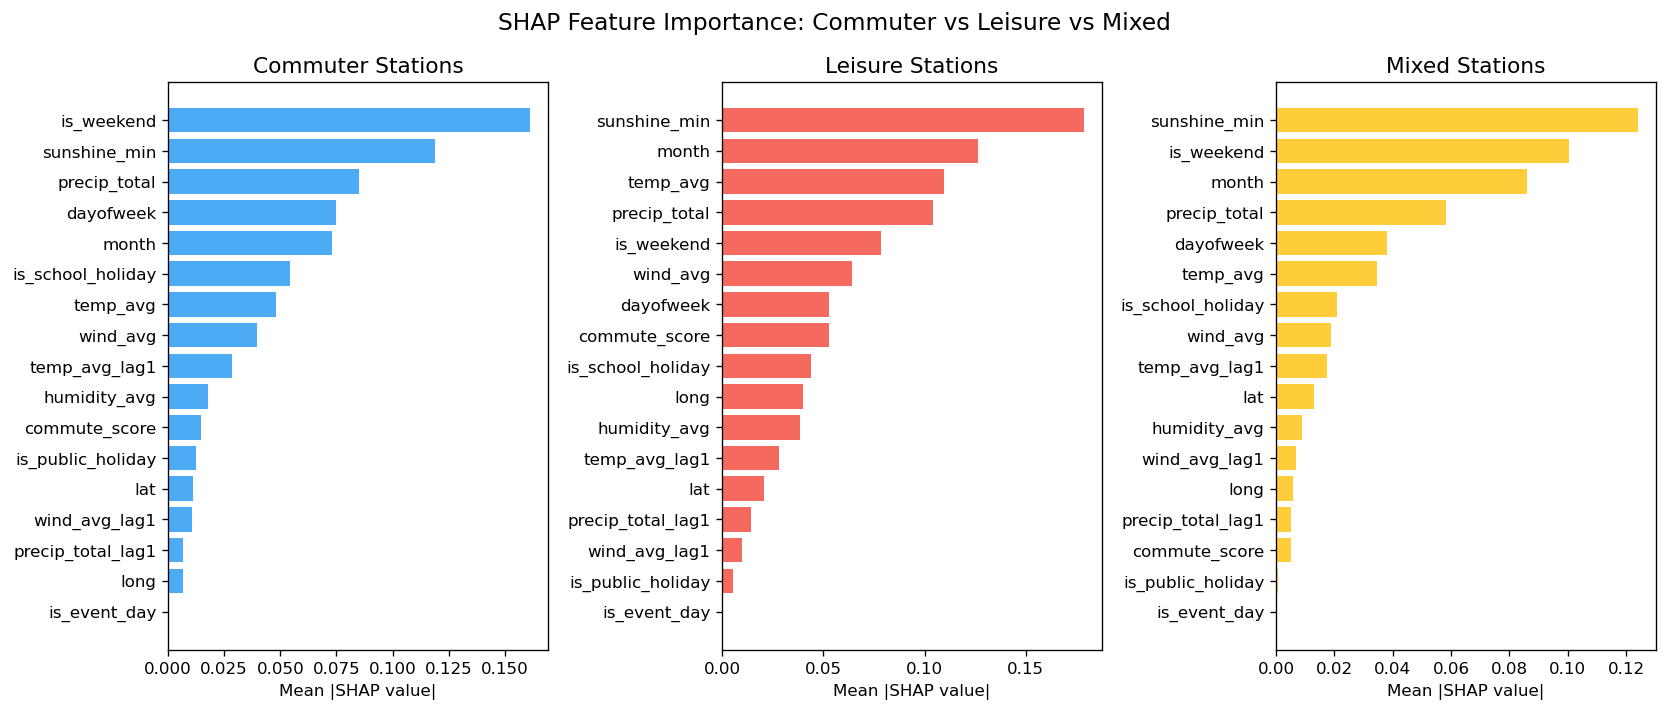

08b_lgbm_reg_shap_summary_comparison.png saved.


In [37]:
# Fig C — Commuter vs Leisure vs Mixed SHAP summary (side-by-side mean |SHAP| bar)
fig_c, (ax_left, ax_right, ax_center) = plt.subplots(1, 3, figsize=(14, 6))

for ax, shap_vals, title, color in [
    (ax_left,   shap_c, "Commuter Stations", COLORS["commuter"]),
    (ax_right,  shap_l, "Leisure Stations",  COLORS["leisure"]),
    (ax_center, shap_m, "Mixed Stations",    COLORS["mixed"]),
]:
    mean_abs = np.abs(shap_vals).mean(axis=0)
    order = np.argsort(mean_abs)
    ax.barh(
        [ALL_FEATURES[i] for i in order],
        mean_abs[order],
        color=color,
        alpha=0.8,
    )
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(title, fontsize=13)

fig_c.suptitle("SHAP Feature Importance: Commuter vs Leisure vs Mixed", fontsize=14)
fig_c.tight_layout()
fig_c.savefig(FIGS / "08b_lgbm_reg_shap_summary_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("08b_lgbm_reg_shap_summary_comparison.png saved.")


/var/folders/99/f5nk7g8n09g1gdgwc7k9scjc0000gn/T/ipykernel_77531/3253239553.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_full, X_shap_full, feature_names=ALL_FEATURES, show=False)


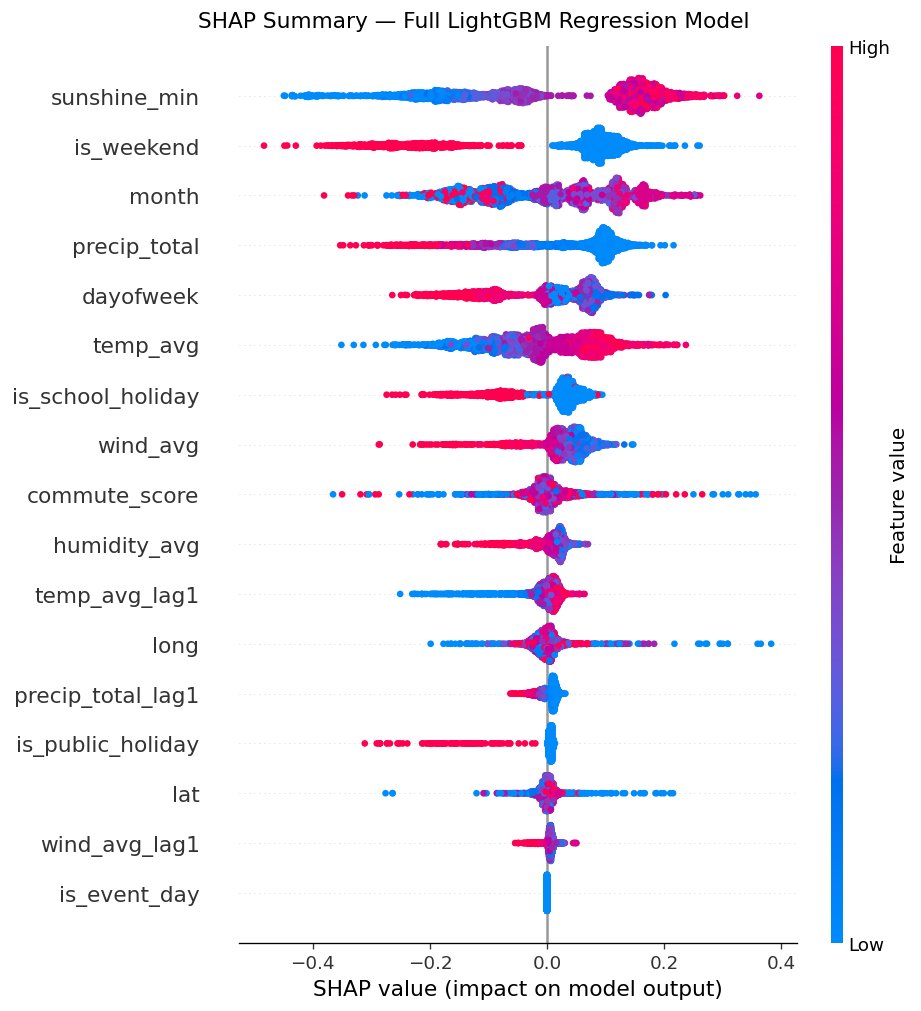

08b_lgbm_reg_shap_summary_full.png saved.


In [38]:
N_SHAP = 3000
rng = np.random.default_rng(42)

idx_shap_full = rng.choice(len(X_test_full), size=min(N_SHAP, len(X_test_full)), replace=False)
X_shap_full   = X_test_full[idx_shap_full]

explainer_full   = shap.TreeExplainer(lgb_full)
shap_values_full = explainer_full.shap_values(X_shap_full)

# Fig A — SHAP summary plot (full model)
shap.summary_plot(shap_values_full, X_shap_full, feature_names=ALL_FEATURES, show=False)
fig_a = plt.gcf()
fig_a.suptitle("SHAP Summary — Full LightGBM Regression Model", fontsize=13, y=1.01)
fig_a.savefig(FIGS / "08b_lgbm_reg_shap_summary_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("08b_lgbm_reg_shap_summary_full.png saved.")


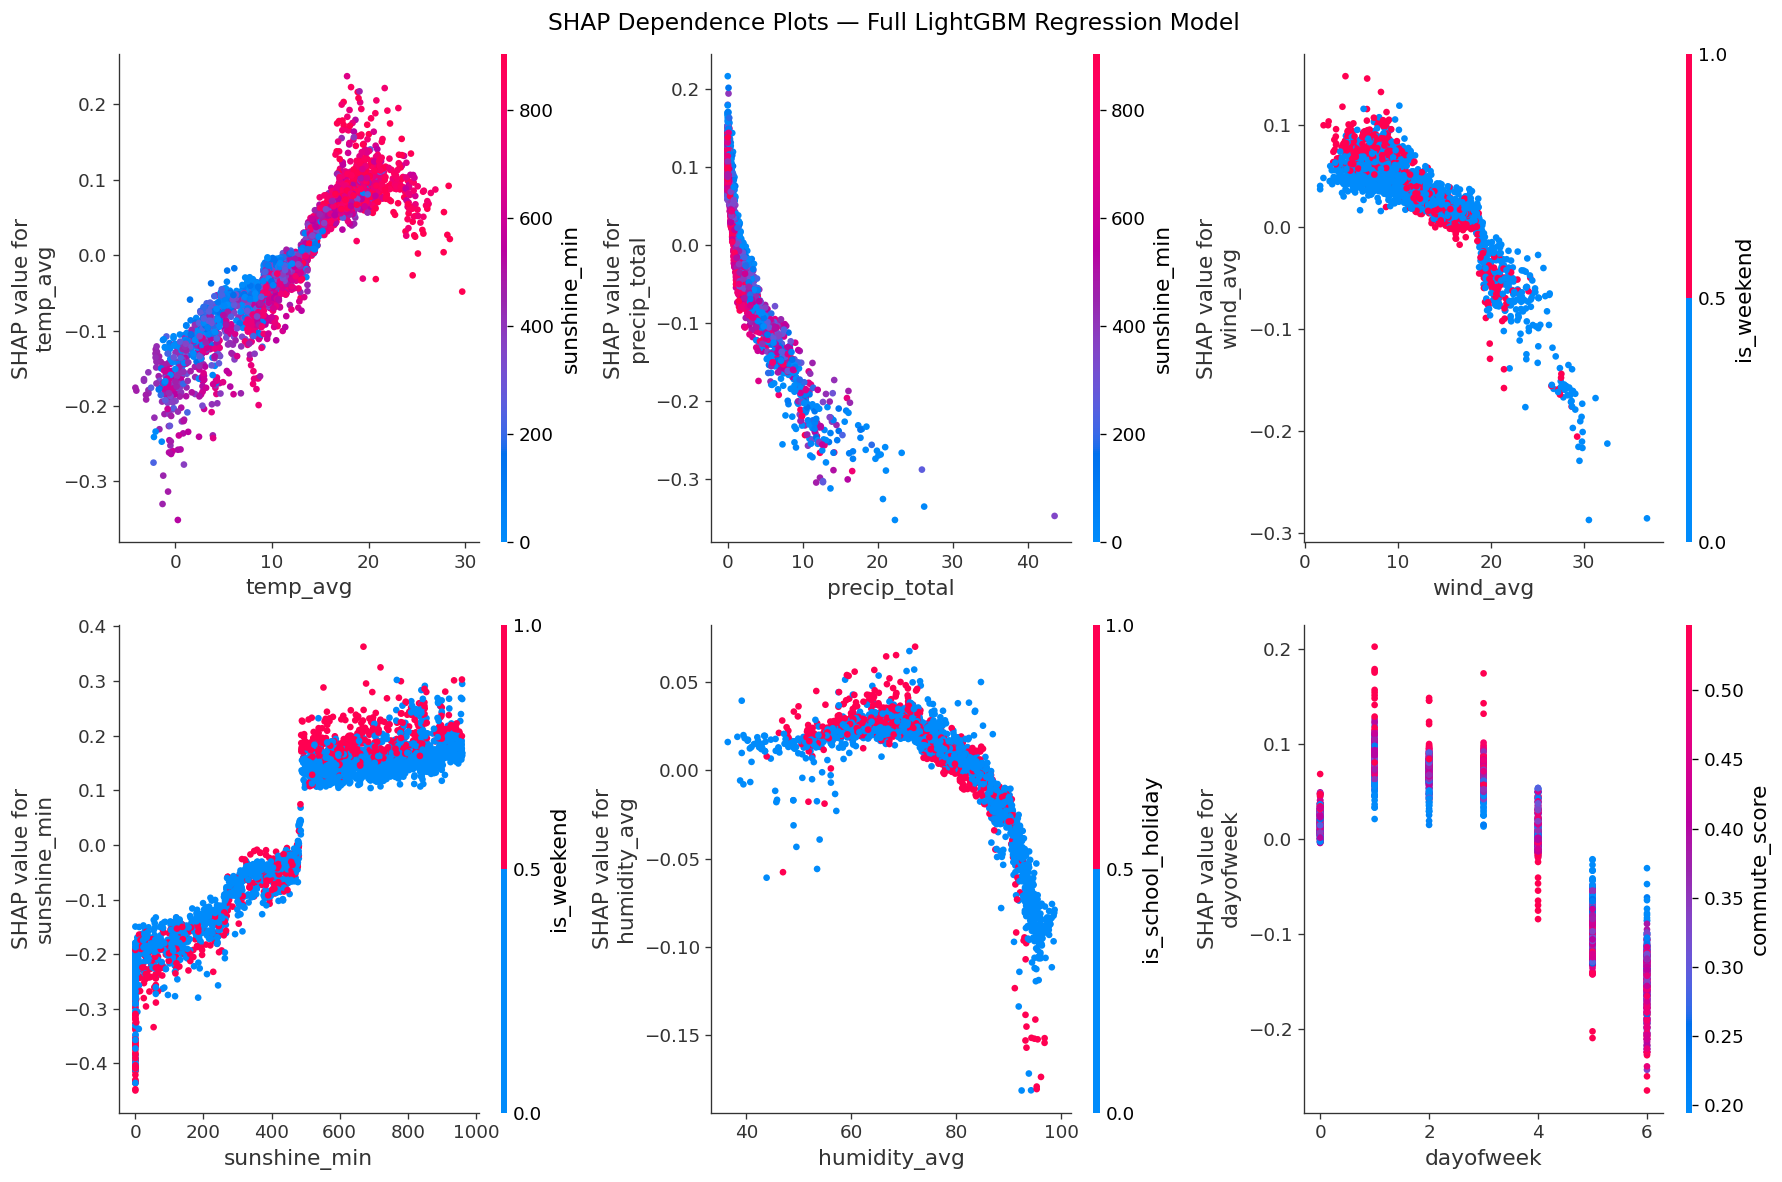

08b_lgbm_reg_shap_dependence_full.png saved.


In [39]:
# Fig B — SHAP dependence plots (2×3 grid, full model)
dep_features = ["temp_avg", "precip_total", "wind_avg",
                "sunshine_min", "humidity_avg", "dayofweek"]

fig_b, axes_b = plt.subplots(2, 3, figsize=(15, 10))
axes_flat = axes_b.flatten()

X_shap_df = pd.DataFrame(X_shap_full, columns=ALL_FEATURES)
for i, feat in enumerate(dep_features):
    shap.dependence_plot(
        feat,
        shap_values_full,
        X_shap_df,
        ax=axes_flat[i],
        show=False,
    )

fig_b.suptitle("SHAP Dependence Plots — Full LightGBM Regression Model", fontsize=14)
fig_b.tight_layout()
fig_b.savefig(FIGS / "08b_lgbm_reg_shap_dependence_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("08b_lgbm_reg_shap_dependence_full.png saved.")


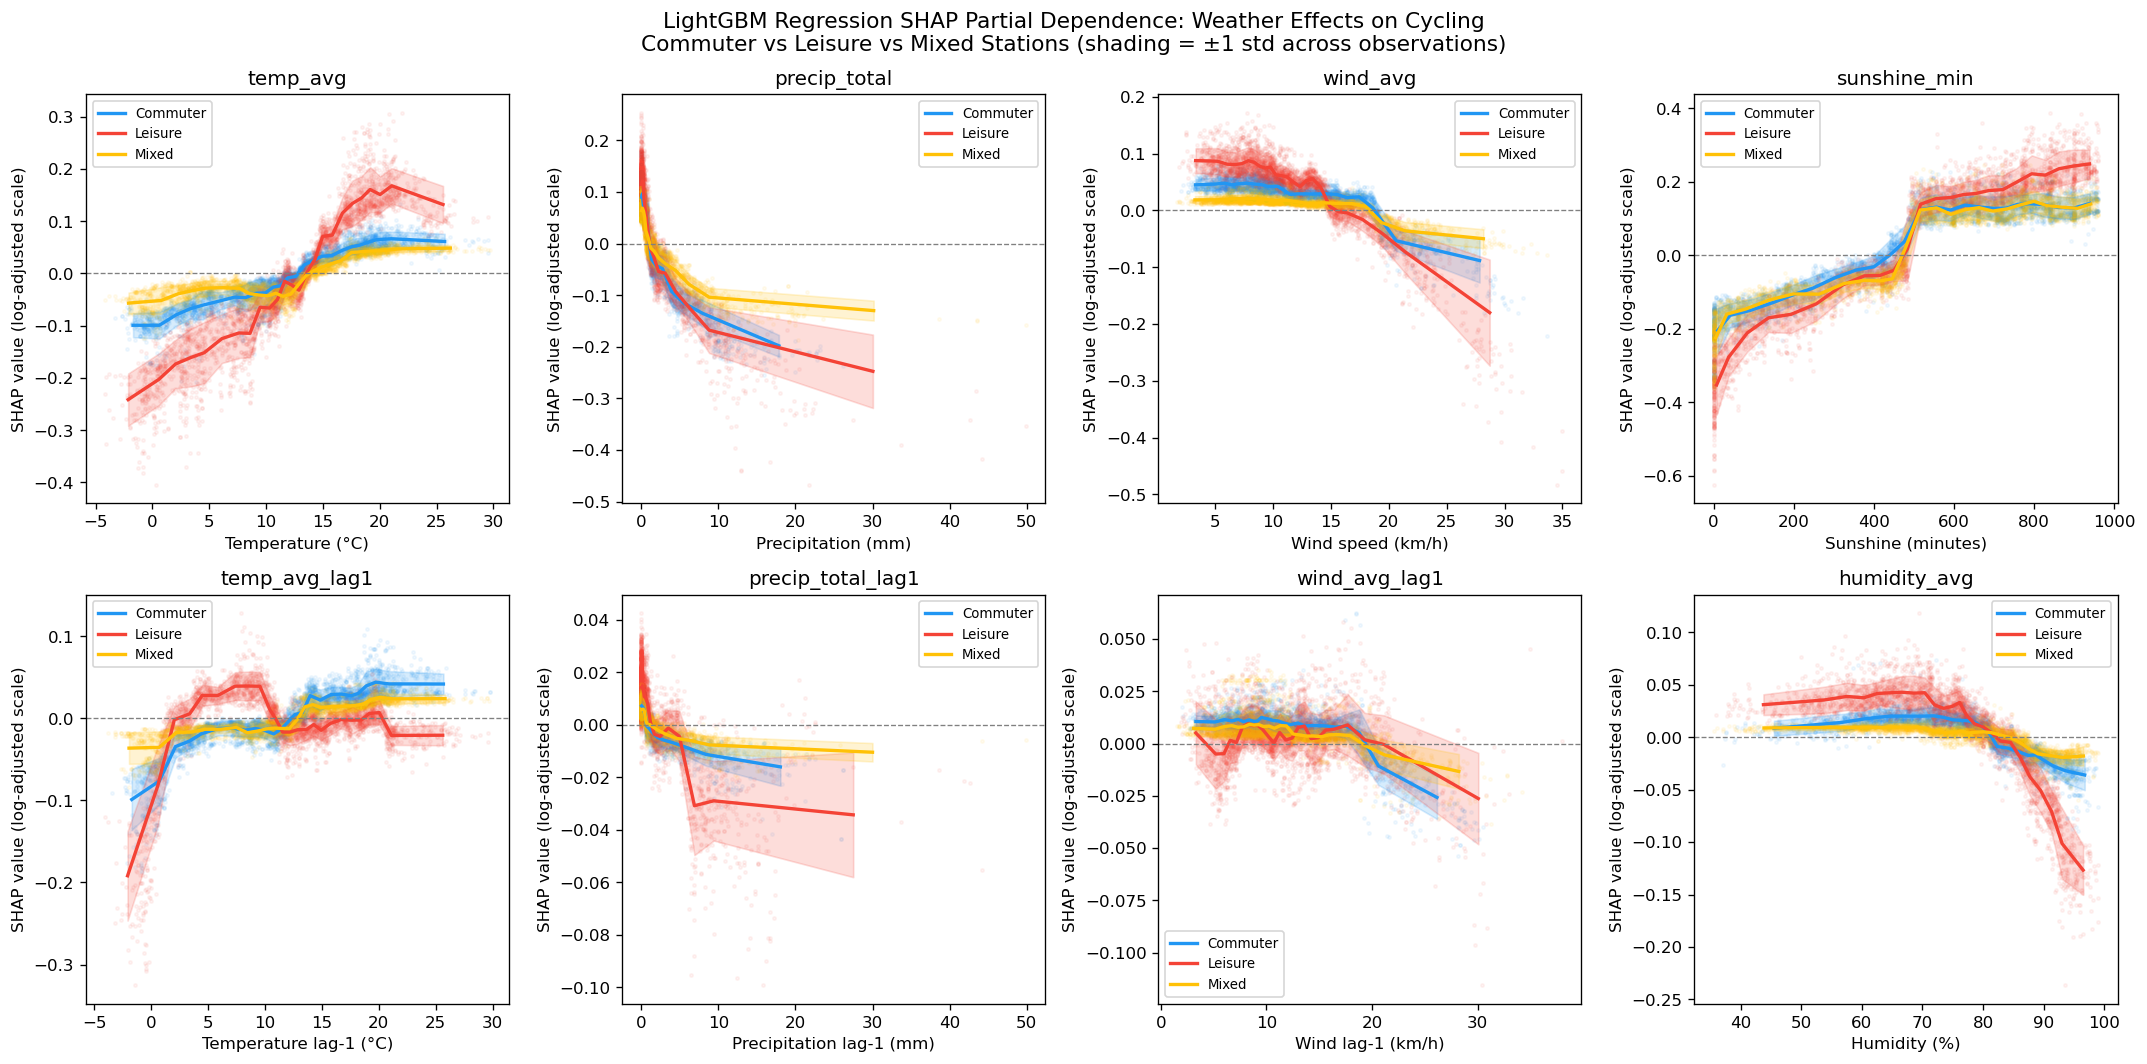

08b_lgbm_reg_shap_pdp.png saved.


In [40]:
def shap_smooth(x_vals, shap_vals, n_bins=25):
    """Bin x and return bin centres + mean ± std of SHAP values per bin."""
    bins = np.percentile(x_vals, np.linspace(0, 100, n_bins + 1))
    bins = np.unique(bins)
    centres, means, stds = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (x_vals >= lo) & (x_vals < hi)
        if mask.sum() < 3:
            continue
        centres.append((lo + hi) / 2)
        means.append(shap_vals[mask].mean())
        stds.append(shap_vals[mask].std())
    return np.array(centres), np.array(means), np.array(stds)

# 2×4 grid — same layout as notebook 08 fig20
weather_terms = [
    (0, "temp_avg",          "Temperature (°C)"),
    (1, "precip_total",      "Precipitation (mm)"),
    (2, "wind_avg",          "Wind speed (km/h)"),
    (3, "sunshine_min",      "Sunshine (minutes)"),
    (5, "temp_avg_lag1",     "Temperature lag-1 (°C)"),
    (6, "precip_total_lag1", "Precipitation lag-1 (mm)"),
    (7, "wind_avg_lag1",     "Wind lag-1 (km/h)"),
    (4, "humidity_avg",      "Humidity (%)"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, (feat_idx, feat_name, xlabel) in zip(axes, weather_terms):
    x_c = X_test_c[idx_c_s, feat_idx]
    x_l = X_test_l[idx_l_s, feat_idx]
    x_m = X_test_m[idx_m_s, feat_idx]
    s_c = shap_c[:, feat_idx]
    s_l = shap_l[:, feat_idx]
    s_m = shap_m[:, feat_idx]
    ax.scatter(x_c, s_c, alpha=0.06, s=4, color=COLORS["commuter"])
    ax.scatter(x_l, s_l, alpha=0.06, s=4, color=COLORS["leisure"])
    ax.scatter(x_m, s_m, alpha=0.06, s=4, color=COLORS["mixed"])
    for x_v, s_v, color, label in [
        (x_c, s_c, COLORS["commuter"], "Commuter"),
        (x_l, s_l, COLORS["leisure"],  "Leisure"),
        (x_m, s_m, COLORS["mixed"],    "Mixed"),
    ]:
        cx, cm, cs = shap_smooth(x_v, s_v)
        ax.plot(cx, cm, color=color, linewidth=2, label=label)
        ax.fill_between(cx, cm - cs, cm + cs, alpha=0.18, color=color)

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("SHAP value (log-adjusted scale)")
    ax.set_title(feat_name)
    ax.legend(fontsize=8)

fig.suptitle(
    "LightGBM Regression SHAP Partial Dependence: Weather Effects on Cycling\n"
    "Commuter vs Leisure vs Mixed Stations (shading = ±1 std across observations)",
    fontsize=13,
)
fig.tight_layout()
fig.savefig(FIGS / "08b_lgbm_reg_shap_pdp.png", dpi=150)
plt.show()
print("08b_lgbm_reg_shap_pdp.png saved.")


## 9. Weather-Normalized Cycling Index

Saved: normalized_cycling_index_lgbm_reg.csv


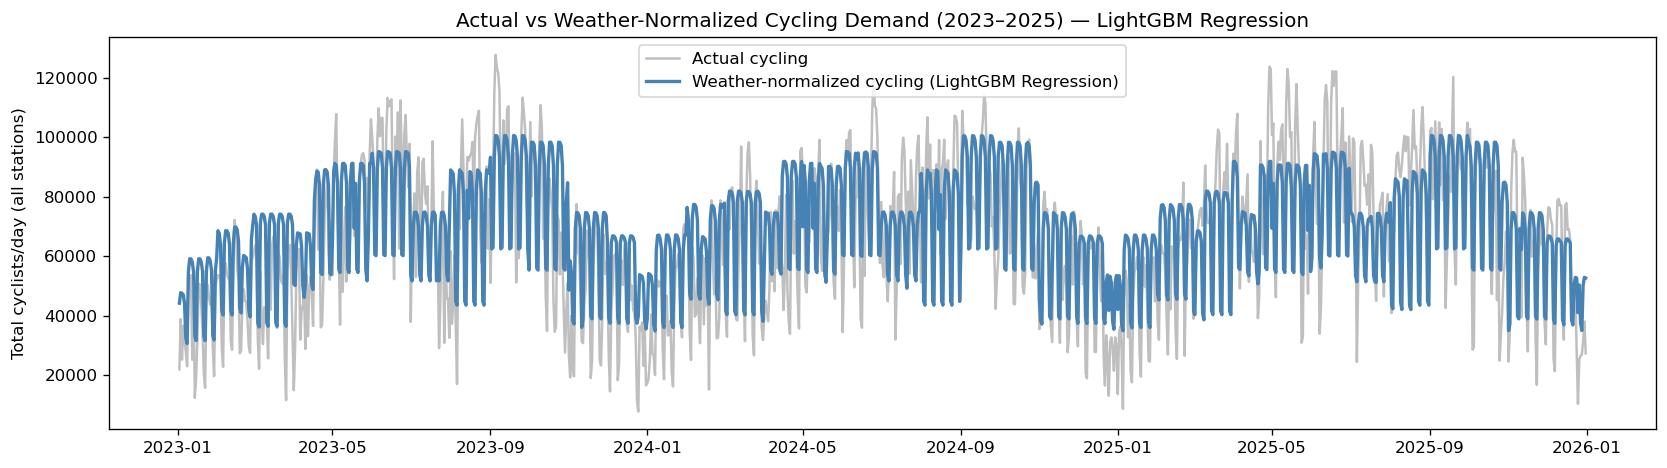

08b_lgbm_reg_normalized_vs_actual.png saved.


In [41]:
ref_weather = {
    "temp_avg"          : 15.0,
    "precip_total"      : 0.0,
    "wind_avg"          : 10.0,
    "sunshine_min"      : 300.0,
    "humidity_avg"      : 70.0,
    "temp_avg_lag1"     : 15.0,
    "precip_total_lag1" : 0.0,
    "wind_avg_lag1"     : 10.0,
}

panel_norm = panel_good.copy()
panel_norm["date"] = pd.to_datetime(panel_norm["date"])
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    panel_norm[col] = panel_norm[col].astype(int)

cols_needed = ALL_FEATURES + ["site_offset"]
extra_cols  = ["site ID", "naam", "date", "aantal", "site_type", "day_type", "season"]
avail_extra = [c for c in extra_cols if c in panel_norm.columns]
panel_norm_clean = panel_norm[cols_needed + avail_extra].dropna(subset=cols_needed)

X_norm = panel_norm_clean[ALL_FEATURES].values.copy().astype(np.float64)
for feat, val_ref in ref_weather.items():
    idx = ALL_FEATURES.index(feat)
    X_norm[:, idx] = val_ref

offset = panel_norm_clean["site_offset"].values
panel_norm_clean = panel_norm_clean.copy()
panel_norm_clean["normalized_count"] = np.clip(
    np.expm1(lgb_full.predict(X_norm) + offset), 0, None
)

out_cols = ["site ID", "naam", "date", "aantal", "normalized_count"] + \
           [c for c in ["site_type", "day_type", "season"] if c in panel_norm_clean.columns]
panel_norm_clean[out_cols].to_csv(
    PROCESSED / "normalized_cycling_index_lgbm_reg.csv", index=False
)
print("Saved: normalized_cycling_index_lgbm_reg.csv")

daily_actual = panel_norm_clean.groupby("date")["aantal"].sum()
daily_norm   = panel_norm_clean.groupby("date")["normalized_count"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_actual.index, daily_actual.values, alpha=0.5, color="gray", label="Actual cycling")
ax.plot(daily_norm.index,   daily_norm.values,   color="steelblue", linewidth=2,
        label="Weather-normalized cycling (LightGBM Regression)")
ax.set_title("Actual vs Weather-Normalized Cycling Demand (2023–2025) — LightGBM Regression")
ax.set_ylabel("Total cyclists/day (all stations)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "08b_lgbm_reg_normalized_vs_actual.png", dpi=150)
plt.show()
print("08b_lgbm_reg_normalized_vs_actual.png saved.")


**1. Weather is the primary driver of seasonal fluctuations**

The seasonal amplitude of the actual cycling curve (grey) is far larger than the normalized curve (blue). During winter months, actual counts fall substantially below normalized levels, indicating that the winter cycling drop is largely attributable to adverse weather conditions rather than a genuine collapse in underlying demand.

**2. Calendar effects are fully preserved after normalization**

The blue curve retains a clear high-frequency oscillation throughout the entire period, reflecting the day-of-week effect (weekend peaks vs. weekday troughs).

**3. No evident growth trend in baseline cycling demand across three years**

The normalized curve holds a broadly stable mid-range level from 2023 through 2025, with no sustained upward trend.


## 10. Weather Effect Magnitudes

In [42]:
median_offset_full = train_clean_full["site_offset"].median()
median_offset_c    = train_clean_c["site_offset"].median()
median_offset_l    = train_clean_l["site_offset"].median()
median_offset_m    = train_clean_m["site_offset"].median()

REF = {
    "temp_avg"         : 15.0,
    "precip_total"     : 0.0,
    "wind_avg"         : 10.0,
    "sunshine_min"     : 300.0,
    "humidity_avg"     : 70.0,
    "temp_avg_lag1"    : 15.0,
    "precip_total_lag1": 0.0,
    "wind_avg_lag1"    : 10.0,
    "dayofweek"        : 2,
    "month"            : 6,
    "is_weekend"       : 0,
    "is_public_holiday": 0,
    "is_school_holiday": 0,
    "is_event_day"     : 0,
    "commute_score"    : float(train_clean_full["commute_score"].median()),
    "lat"              : float(train_clean_full["lat"].median()),
    "long"             : float(train_clean_full["long"].median()),
}

def weather_effect_lgbm_reg(model, feature, bad_val, ref_val, offset):
    base = np.array([[REF[f] for f in ALL_FEATURES]] * 100, dtype=float)
    feat_idx = ALL_FEATURES.index(feature)
    X_bad = base.copy(); X_bad[:, feat_idx] = bad_val
    X_ref = base.copy(); X_ref[:, feat_idx] = ref_val
    y_bad = np.expm1(model.predict(X_bad) + offset).mean()
    y_ref = np.expm1(model.predict(X_ref) + offset).mean()
    return (y_bad - y_ref) / y_ref * 100

comparisons = [
    ("Heavy rain (20mm vs 0mm)",    "precip_total",  20.0,   0.0),
    ("Light rain (2mm vs 0mm)",     "precip_total",   2.0,   0.0),
    ("Cold day (0°C vs 15°C)",      "temp_avg",       0.0,  15.0),
    ("Cool day (8°C vs 15°C)",      "temp_avg",       8.0,  15.0),
    ("Strong wind (40 vs 10 km/h)", "wind_avg",      40.0,  10.0),
    ("No sunshine (0 vs 300 min)",  "sunshine_min",   0.0, 300.0),
]

print("=" * 80)
print("LGBM REGRESSION WEATHER EFFECT SIZES")
print("=" * 80)
print(f"{'Condition':<35} | {'Full':>7} | {'Commuter':>9} | {'Leisure':>8} | {'Mixed':>7}")
print("-" * 80)
for label, feat, bad_val, ref_val in comparisons:
    ef = weather_effect_lgbm_reg(lgb_full,     feat, bad_val, ref_val, median_offset_full)
    ec = weather_effect_lgbm_reg(lgb_commuter, feat, bad_val, ref_val, median_offset_c)
    el = weather_effect_lgbm_reg(lgb_leisure,  feat, bad_val, ref_val, median_offset_l)
    em = weather_effect_lgbm_reg(lgb_mixed,    feat, bad_val, ref_val, median_offset_m)
    print(f"{label:<35} | {ef:>6.1f}% | {ec:>8.1f}% | {el:>7.1f}% | {em:>7.1f}%")
print("=" * 80)


LGBM REGRESSION WEATHER EFFECT SIZES
Condition                           |    Full |  Commuter |  Leisure |   Mixed
--------------------------------------------------------------------------------
Heavy rain (20mm vs 0mm)            |  -35.4% |    -32.8% |   -37.1% |   -26.9%
Light rain (2mm vs 0mm)             |  -14.5% |     -6.8% |   -23.5% |   -14.8%
Cold day (0°C vs 15°C)              |   -7.5% |     -8.1% |   -22.0% |    -4.9%
Cool day (8°C vs 15°C)              |   -4.9% |     -6.7% |   -14.2% |    -4.9%
Strong wind (40 vs 10 km/h)         |  -19.8% |    -11.8% |   -27.2% |    -1.6%
No sunshine (0 vs 300 min)          |  -13.4% |    -11.5% |   -19.5% |    -9.8%


## 11. Save Models

In [43]:
models = {
    "lgb_full"        : lgb_full,
    "lgb_commuter"    : lgb_commuter,
    "lgb_leisure"     : lgb_leisure,
    "lgb_mixed"       : lgb_mixed,
    "model_type"      : "lightgbm_regression",
    "site_offset_test": site_offset_test,
    "ALL_FEATURES"    : ALL_FEATURES,
    "ref_weather"     : ref_weather,
}
with open(PROCESSED / "lgbm_regression_models.pkl", "wb") as fh:
    pickle.dump(models, fh)
print(f"Models saved to {PROCESSED / 'lgbm_regression_models.pkl'}")


Models saved to /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/processed/lgbm_regression_models.pkl


## 12. Final Summary

In [44]:
heavy_rain_full = weather_effect_lgbm_reg(lgb_full, "precip_total",  20.0,   0.0, median_offset_full)
cold_day_full   = weather_effect_lgbm_reg(lgb_full, "temp_avg",       0.0,  15.0, median_offset_full)
strong_wind_full= weather_effect_lgbm_reg(lgb_full, "wind_avg",      40.0,  10.0, median_offset_full)

print("=" * 52)
print("LIGHTGBM REGRESSION MODELLING SUMMARY")
print("=" * 52)
print(f"Training period : 2023–2024 ({len(y_train_full):,} observations)")
print(f"Test period     : 2025     ({len(y_test_full):,} observations)")
print()
print("Model performance (test set):")
print(f"  Full LightGBM     : MAE={test_mae:.1f}, R²={test_r2:.3f}")
print(f"  Commuter LightGBM : MAE={mae_c:.1f}, R²={r2_c:.3f}")
print(f"  Leisure LightGBM  : MAE={mae_l:.1f}, R²={r2_l:.3f}")
print(f"  Mixed LightGBM    : MAE={mae_m:.1f}, R²={r2_m:.3f}")
print()
print("Key weather effects on cycling demand (full model):")
print(f"  Heavy rain (20mm) : {heavy_rain_full:+.1f}%")
print(f"  Cold day (0°C)    : {cold_day_full:+.1f}%")
print(f"  Strong wind       : {strong_wind_full:+.1f}%")


LIGHTGBM REGRESSION MODELLING SUMMARY
Training period : 2023–2024 (95,400 observations)
Test period     : 2025     (47,842 observations)

Model performance (test set):
  Full LightGBM     : MAE=121.2, R²=0.880
  Commuter LightGBM : MAE=122.8, R²=0.902
  Leisure LightGBM  : MAE=111.8, R²=0.866
  Mixed LightGBM    : MAE=144.5, R²=0.765

Key weather effects on cycling demand (full model):
  Heavy rain (20mm) : -35.4%
  Cold day (0°C)    : -7.5%
  Strong wind       : -19.8%
